# Backend Kilobytes Calculation and Verification of Its Independence of Dedup Ratio

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import warnings

%matplotlib inline

In [2]:
dat = pd.read_csv(
    "../data/5150/8.2/default/throughput.average", sep= " ",
    header=None)
dat.columns = ["dedup_ratio", "num_streams", "kb_transferred", "elapsed_time", "kb_throughput"]           
dat["bekb"] = ((100 - dat["dedup_ratio"].values) * dat["kb_transferred"].values) / dat["elapsed_time"].values

dat.head()

,dedup_ratio,num_streams,kb_transferred,elapsed_time,kb_throughput,bekb
0,0,1,30735,595,51,5165.546218
1,0,2,61470,1191,51,5161.209068
2,0,4,122940,2470,49,4977.327935
3,0,8,245880,5039,51,4879.539591
4,0,10,307350,6315,52,4866.983373


## Analysis with Full Dataset

In [3]:
model = smf.ols(formula="bekb ~ dedup_ratio + np.power(dedup_ratio, 2)", data=dat)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   bekb   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     45.85
Date:                Thu, 08 Oct 2020   Prob (F-statistic):           1.42e-07
Time:                        09:21:46   Log-Likelihood:                -154.69
No. Observations:                  20   AIC:                             315.4
Df Residuals:                      17   BIC:                             318.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                 4932.0664    267.357     18.448      0.000    4367.993    5496.140
dedup_ratio                 52.5813     13.106      4.012      0.001      24.930      80.232
np.power(dedup_ratio, 2)    -0.8291      0.133     -6.255      0.000      -1.109      -0.549
==============================================================================
Omnibus:                        0.386   Durbin-Watson:                   1.111
Prob(Omnibus):                  0.825   Jarque-Bera (JB):                0.256
Skew:                          -0.247   Prob(JB):                        0.880
Kurtosis:                       2.750   Cond. No.                     1.18e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.18e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

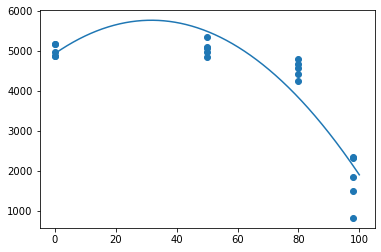

In [4]:
dedup_values = np.linspace(0.001, 99.999, num=1000)
pred_values = results.predict(pd.DataFrame({"dedup_ratio": dedup_values}))

plt.scatter(dat["dedup_ratio"], dat["bekb"])
plt.plot(dedup_values, pred_values);

## Ignoring High Dedup Ratio Values

In [5]:
dat_under_98_dedup = dat.loc[dat["dedup_ratio"] < 98]

model = smf.ols(formula="bekb ~ dedup_ratio + np.power(dedup_ratio, 2)", data=dat_under_98_dedup)
results = model.fit()
# ignore the UserWarning from the lack of inputs
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    summary = results.summary()
summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   bekb   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     12.42
Date:                Thu, 08 Oct 2020   Prob (F-statistic):            0.00120
Time:                        09:21:49   Log-Likelihood:                -97.721
No. Observations:                  15   AIC:                             201.4
Df Residuals:                      12   BIC:                             203.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                 5010.1212     81.666     61.349      0.000    4832.186    5188.056
dedup_ratio                 12.6240      5.377      2.348      0.037       0.909      24.339
np.power(dedup_ratio, 2)    -0.2312      0.067     -3.432      0.005      -0.378      -0.084
==============================================================================
Omnibus:                        0.528   Durbin-Watson:                   1.101
Prob(Omnibus):                  0.768   Jarque-Bera (JB):                0.551
Skew:                          -0.013   Prob(JB):                        0.759
Kurtosis:                       2.062   Cond. No.                     6.88e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.88e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

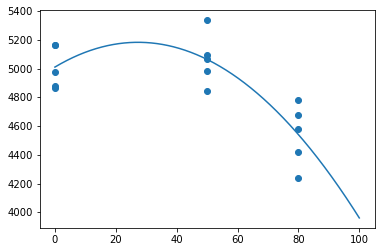

In [6]:
dedup_values = np.linspace(0.001, 99.999, num=1000)
pred_values = results.predict(pd.DataFrame({"dedup_ratio": dedup_values}))

plt.scatter(dat_under_98_dedup["dedup_ratio"], dat_under_98_dedup["bekb"])
plt.plot(dedup_values, pred_values);